In [131]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.signal as signal
import sys
import os
sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

%load_ext autoreload
%autoreload 2
import src.processing_functions as pf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data and Extract Features

In [56]:
df = pd.read_csv("../data/intermediate/pamap_cleaned_df.csv")

X , y, subjects = pf.pull_features_per_subject(df)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

## Model Training

In [118]:
# XGBoost Classifier
XGB_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric="mlogloss", random_state=42)

# Random Forest Classifier
RF_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, n_jobs=-1, random_state=42)

# Regression Tree Classifier
DT_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

# Logistic Regression Classifier
LR_model = Pipeline([
("scaler", StandardScaler()),
("model", LogisticRegression(max_iter=5000, random_state=42))
])

models = {
    "DecisionTree": DT_model,
    "RandomForest": RF_model,
    "XGBoost": XGB_model,
    "LogisticRegression": LR_model
}

In [120]:
def LOGO_model_training(X, y_encoded, subjects, model):
    """Train a model using Leave-One-Group-Out cross-validation and return true and predicted labels."""
   
    logo = LeaveOneGroupOut()
    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in logo.split(X, y_encoded, groups=subjects):
        print(f"Train subjects: {set(subjects[train_idx])}, Test subject: {set(subjects[test_idx])}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        # train model
        model.fit(X_train, y_train)

        # predict
        y_pred = model.predict(X_test)
        #print(classification_report(y_test, y_pred, zero_division=0))

        # accumulate
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    return all_y_true, all_y_pred

In [121]:
model_results = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    y_true, y_pred = LOGO_model_training(X, y_encoded, subjects, model)
    model_results[model_name] = (y_true, y_pred)

Training DecisionTree...
Train subjects: {1, 2, 3, 4, 5, 6, 7, 8}, Test subject: {0}
Train subjects: {0, 2, 3, 4, 5, 6, 7, 8}, Test subject: {1}
Train subjects: {0, 1, 3, 4, 5, 6, 7, 8}, Test subject: {2}
Train subjects: {0, 1, 2, 4, 5, 6, 7, 8}, Test subject: {3}
Train subjects: {0, 1, 2, 3, 5, 6, 7, 8}, Test subject: {4}
Train subjects: {0, 1, 2, 3, 4, 6, 7, 8}, Test subject: {5}
Train subjects: {0, 1, 2, 3, 4, 5, 7, 8}, Test subject: {6}
Train subjects: {0, 1, 2, 3, 4, 5, 6, 8}, Test subject: {7}
Train subjects: {0, 1, 2, 3, 4, 5, 6, 7}, Test subject: {8}
Training RandomForest...
Train subjects: {1, 2, 3, 4, 5, 6, 7, 8}, Test subject: {0}
Train subjects: {0, 2, 3, 4, 5, 6, 7, 8}, Test subject: {1}
Train subjects: {0, 1, 3, 4, 5, 6, 7, 8}, Test subject: {2}
Train subjects: {0, 1, 2, 4, 5, 6, 7, 8}, Test subject: {3}
Train subjects: {0, 1, 2, 3, 5, 6, 7, 8}, Test subject: {4}
Train subjects: {0, 1, 2, 3, 4, 6, 7, 8}, Test subject: {5}
Train subjects: {0, 1, 2, 3, 4, 5, 7, 8}, Test sub

Confusion Matrix for DecisionTree:


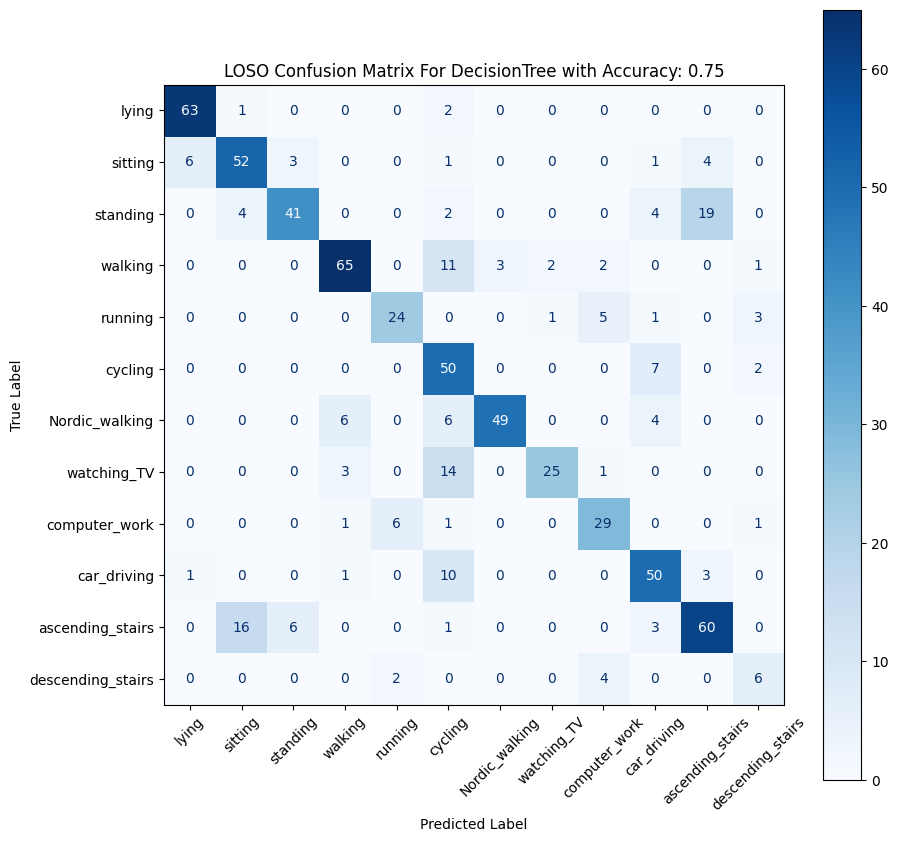

Confusion Matrix for RandomForest:


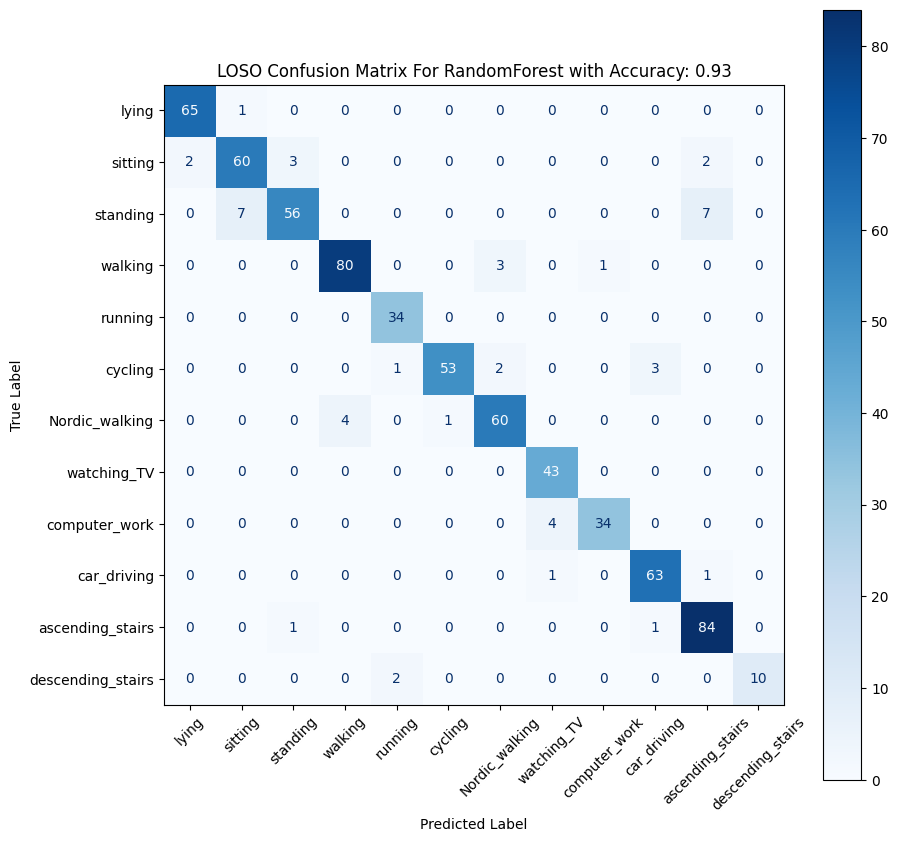

Confusion Matrix for XGBoost:


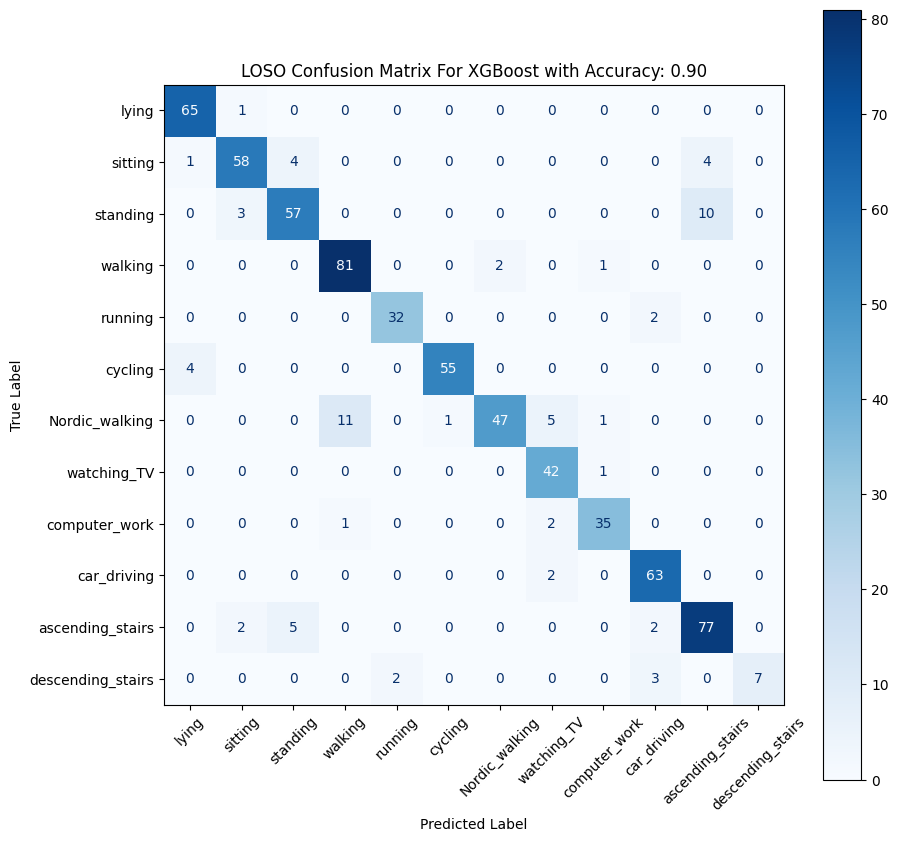

Confusion Matrix for LogisticRegression:


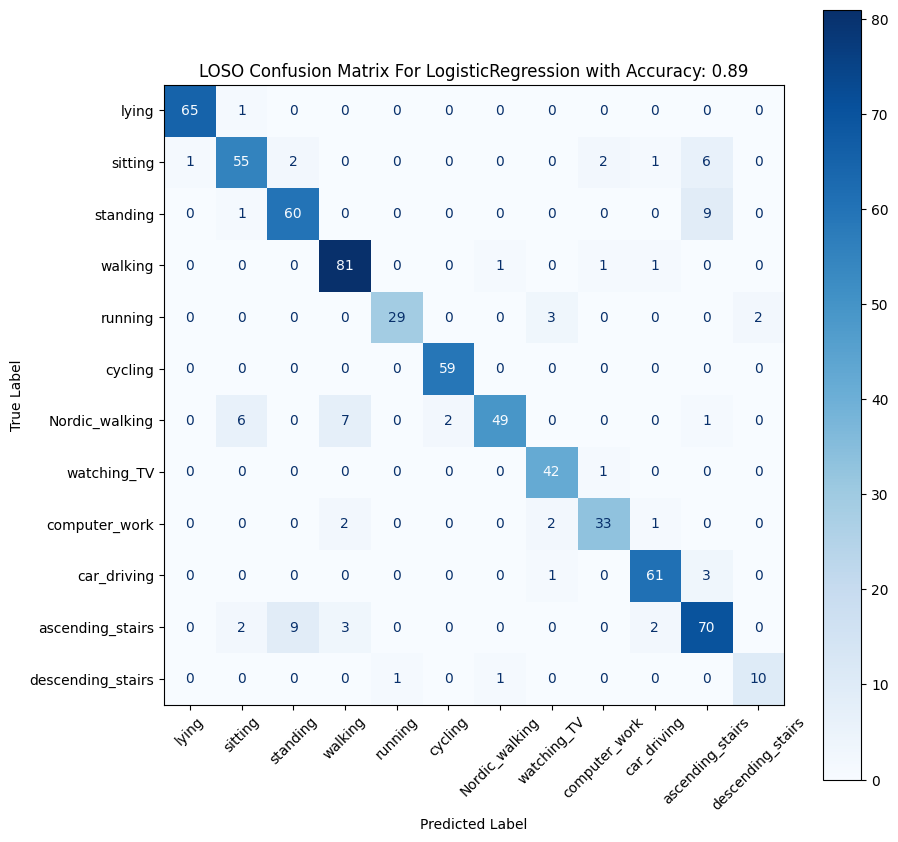

In [125]:
def plot_confusion_matrix_with_accuracy_score(y_true, y_pred, model_name):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    display_labels = [pf.ACTIVITY_LABEL_MAP[i] for i in labels]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=ax)

    plt.title(f"LOSO Confusion Matrix For {model_name} with Accuracy: {accuracy_score(y_true, y_pred):.2f}")
    plt.xlabel(f"Predicted Label")
    plt.ylabel(f"True Label")
    plt.show()


for model_name, (y_true, y_pred) in model_results.items():
    print(f"Confusion Matrix for {model_name}:")
    plot_confusion_matrix_with_accuracy_score(y_true, y_pred, model_name)

In [126]:
importances =XGB_model.feature_importances_
feature_names = X.columns

# plt.figure(figsize=(12, 30), layout="tight")
# plt.barh(feature_names, importances)
# plt.xlabel("Feature Importance")
# plt.ylabel("Feature")
# plt.title("Feature Importances from XGBoost")

In [127]:
# from sklearn.inspection import permutation_importance

# r = permutation_importance(
#     XGB_model,
#     X_test,
#     y_test,
#     n_repeats=10,
#     random_state=42,
#     n_jobs=-1
# )

# global_importance = pd.Series(r.importances_mean, index=X.columns)

In [128]:
# class_importance = {}

# for c in np.unique(y_test):
#     mask = y_test == c

#     if mask.sum() < 5:
#         continue

#     r = permutation_importance(
#         XGB_model,
#         X_test[mask],
#         y_test[mask],
#         n_repeats=5,
#         random_state=42,
#         n_jobs=-1
#     )

#     class_importance[c] = r.importances_mean

In [130]:
# importance_df = pd.DataFrame(class_importance, index=X.columns)
# importance_df.columns = [pf.ACTIVITY_LABEL_MAP[c] for c in importance_df.columns]
# plt.figure(figsize=(12, 30))
# sns.heatmap(importance_df, cmap="viridis")
# plt.title("Feature Importance by Activity")
# plt.show()

## Hyperparameter Optimization

In [ ]:
mod = GridSearchCV(estimator=pipe,
                  param_grid={'model__n_estimators': [50, 100, 200],
                              'model__max_depth': [3, 5, 10],
                              'model__learning_rate': [0.001, 0.01, 0.05]
                              },
                  cv = logo,
                  scoring= 'roc_auc',
                  n_jobs =-1)

mod.fit(X,y, groups=groups)

print(mod.best_params_)
print(mod.best_score_)

pd.DataFrame(mod.cv_results_)